In [1]:
!pip install --quiet --no-deps byol-pytorch==0.8.2 timm opencv-python-headless tqdm scikit-learn


In [2]:
# ===========================
# Common setup (run once)
# ===========================
import os, random, math, pickle, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms, datasets, models
from PIL import Image

# reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# Install byol-pytorch in your environment if not present (uncomment)
# !pip install --quiet --no-deps byol-pytorch==0.8.2 timm opencv-python-headless tqdm scikit-learn

from byol_pytorch import BYOL
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

# --- dataset for unlabeled images (recursively) ---
class DentalUnlabeledDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        for subdir, _, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    self.image_paths.append(os.path.join(subdir, f))
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img

# --- strong BYOL transforms (typical) ---
transform_unlabeled = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224, scale=(0.5,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ToTensor(),
])

# ---------- paths ----------
unlabeled_root = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography/train"  # adapt
unlabeled_ds = DentalUnlabeledDataset(unlabeled_root, transform=transform_unlabeled)
print("Unlabeled images:", len(unlabeled_ds))
unlabeled_loader = DataLoader(unlabeled_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

# ---------- model & BYOL wrapper ----------
backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
# remove classifier to get features
backbone.classifier = nn.Identity()

ssl_model = BYOL(
    backbone,
    image_size=224,
    hidden_layer='avgpool',        # ensures we use pooled features
    projection_size=256,
    projection_hidden_size=4096
).to(device)

optimizer = optim.AdamW(ssl_model.parameters(), lr=1e-4, weight_decay=1e-6)
scaler = torch.cuda.amp.GradScaler()

# ---------- training (short example) ----------
epochs = 10
for epoch in range(epochs):
    ssl_model.train()
    running_loss = 0.0
    for imgs in tqdm(unlabeled_loader, desc=f"BYOL epoch {epoch+1}/{epochs}"):
        imgs = imgs.to(device)
        loss = ssl_model(imgs)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += float(loss.detach().cpu().item()) * imgs.size(0)
    avg_loss = running_loss / len(unlabeled_ds)
    print(f"Epoch {epoch+1} BYOL avg loss: {avg_loss:.4f}")

# ---------- Save only the backbone state_dict (canonical) ----------
# NOTE: `backbone` variable is the actual model instance passed to BYOL
backbone_state_path = "dental_byol_backbone.pth"
torch.save(backbone.state_dict(), backbone_state_path)
print("Saved BYOL backbone state to:", backbone_state_path)


Unlabeled images: 25136


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s] 
/tmp/ipykernel_37/1288499910.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
BYOL epoch 1/10: 100%|██████████| 786/786 [05:33<00:00,  2.36it/s]


Epoch 1 BYOL avg loss: 1.5446


BYOL epoch 2/10: 100%|██████████| 786/786 [05:34<00:00,  2.35it/s]


Epoch 2 BYOL avg loss: 1.4778


...

Epoch 8 BYOL avg loss: 1.3955


BYOL epoch 9/10: 100%|██████████| 786/786 [05:35<00:00,  2.34it/s]


Epoch 9 BYOL avg loss: 1.3864


BYOL epoch 10/10: 100%|██████████| 786/786 [05:39<00:00,  2.31it/s]

Epoch 10 BYOL avg loss: 1.3812
Saved BYOL backbone state to: dental_byol_backbone.pth


In [4]:
# ---------------------------
# Paths & transforms
# ---------------------------
root_path = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography"  # adapt
train_dir = os.path.join(root_path, "train")
val_dir   = os.path.join(root_path, "valid")
test_dir  = os.path.join(root_path, "test")

transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
transform_eval = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(train_dir, transform=transform_train)
val_ds   = datasets.ImageFolder(val_dir, transform=transform_eval)
test_ds  = datasets.ImageFolder(test_dir, transform=transform_eval)
class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)
bs = 32
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

# ==========================
# 🔍 Dataset Shape Inspection
# ==========================
print(f"\n--- Dataset Overview ---")
print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

# Inspect one training batch
imgs, labels = next(iter(train_loader))
print("\n=== Sample Batch Details ===")
print(f"Images shape (X): {imgs.shape}")      # Expect [32, 3, 224, 224]
print(f"Labels shape (Y): {labels.shape}")    # Expect [32]
print(f"Label sample (first 10): {labels[:10].tolist()}")
print(f"Class index mapping: {dict(enumerate(class_names))}\n")
# ==========================

# ---------------------------
# Load backbone and attach classifier head
# ---------------------------
backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()
# load BYOL weights if exist
if os.path.exists("dental_byol_backbone.pth"):
    sd = torch.load("dental_byol_backbone.pth", map_location=device)
    backbone.load_state_dict(sd, strict=False)
    print("Loaded BYOL backbone weights")
else:
    print("BYOL backbone not found, using random init")

# classifier head
num_features = 1280   # EfficientNet-B0 output dim
head = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)

# Full model (wrap backbone -> flatten -> head)
class FullNet(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head
    def forward(self, x):
        feats = self.backbone(x)           # may be [B, C, 1, 1]
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        return self.head(feats)

model = FullNet(backbone, head).to(device)

# freeze most layers, unfreeze last block for fine-tune
for name, p in model.backbone.named_parameters():
    p.requires_grad = False
# Unfreeze last feature blocks (example names may differ; check names in your torchvision version)
for name, p in model.backbone.named_parameters():
    if "features.6" in name or "features.7" in name or "features.5" in name:
        p.requires_grad = True

# criterion (initially uniform)
class_weights = torch.ones(num_classes, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = torch.cuda.amp.GradScaler()

# training loop with val and best checkpoint
num_epochs = 20
best_val_acc = 0.0
history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += float(loss.detach().cpu().item()) * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / len(train_ds)
    train_acc = correct / total

    # validate
    model.eval()
    v_loss = 0.0
    v_correct = 0
    v_total = 0
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            v_loss += float(loss.detach().cpu().item()) * imgs.size(0)
            preds = outputs.argmax(dim=1)
            v_correct += (preds == labels).sum().item()
            v_total += imgs.size(0)
            y_true_val.append(labels.cpu().numpy())
            y_pred_val.append(preds.cpu().numpy())
    val_loss = v_loss / len(val_ds)
    val_acc = v_correct / v_total

    scheduler.step()
    history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_acc": val_acc
        }, "best_finetuned_model.pth")
        print("Saved best_finetuned_model.pth (val_acc improved)")

# save final history
with open("finetune_history.pkl", "wb") as f:
    pickle.dump(history, f)

# quick test eval with the best model loaded
ckpt = torch.load("best_finetuned_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += imgs.size(0)
print("Finetune test acc:", test_correct / test_total)


Classes: ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant', 'Normal']

--- Dataset Overview ---
Train samples: 25136
Validation samples: 2812
Test samples: 1649

=== Sample Batch Details ===
Images shape (X): torch.Size([32, 3, 224, 224])
Labels shape (Y): torch.Size([32])
Label sample (first 10): [1, 4, 1, 1, 4, 4, 1, 4, 0, 4]
Class index mapping: {0: 'Cavity', 1: 'Fillings', 2: 'Impacted Tooth', 3: 'Implant', 4: 'Normal'}

Loaded BYOL backbone weights


/tmp/ipykernel_37/2233679031.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_37/2233679031.py:117: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_37/2233679031.py:139: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: train_acc=0.8483 val_acc=0.9011
Saved best_finetuned_model.pth (val_acc improved)
Epoch 2: train_acc=0.9069 val_acc=0.9147
Saved best_finetuned_model.pth (val_acc improved)
Epoch 3: train_acc=0.9224 val_acc=0.9292
Saved best_finetuned_model.pth (val_acc improved)
Epoch 4: train_acc=0.9328 val_acc=0.9200
Epoch 5: train_acc=0.9415 val_acc=0.9282
Epoch 6: train_acc=0.9512 val_acc=0.9275
Epoch 7: train_acc=0.9576 val_acc=0.9299
Saved best_finetuned_model.pth (val_acc improved)
Epoch 8: train_acc=0.9604 val_acc=0.9339
Saved best_finetuned_model.pth (val_acc improved)
Epoch 9: train_acc=0.9659 val_acc=0.9328
Epoch 10: train_acc=0.9675 val_acc=0.9342
Saved best_finetuned_model.pth (val_acc improved)
Epoch 11: train_acc=0.9674 val_acc=0.9331
Epoch 12: train_acc=0.9675 val_acc=0.9331
Epoch 13: train_acc=0.9668 val_acc=0.9324
Epoch 14: train_acc=0.9677 val_acc=0.9317
Epoch 15: train_acc=0.9670 val_acc=0.9324
Epoch 16: train_acc=0.9661 val_acc=0.9271
Epoch 17: train_acc=0.9671 val_acc=0.

In [6]:
# ============================
# Stage 3 — DANN with Meta-Class Weight Regulation
# ============================

import os, math, torch, pickle
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------------------
# 1️⃣  Load dataset
# ---------------------------
root_path = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography"
train_dir = os.path.join(root_path, "train")
val_dir   = os.path.join(root_path, "valid")
test_dir  = os.path.join(root_path, "test")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(train_dir, transform=transform)
val_ds   = datasets.ImageFolder(val_dir, transform=transform)
test_ds  = datasets.ImageFolder(test_dir, transform=transform)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

bs = 32
train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=bs, shuffle=False, num_workers=4, pin_memory=True)

# ---------------------------
# 2️⃣ Define backbone, classifier, and domain discriminator
# ---------------------------
backbone = models.efficientnet_b0(weights=None)
backbone.classifier = nn.Identity()

if os.path.exists("dental_byol_backbone.pth"):
    state = torch.load("dental_byol_backbone.pth", map_location=device)
    backbone.load_state_dict(state, strict=False)
    print("✅ Loaded BYOL pretrained backbone.")
else:
    print("⚠️ BYOL weights not found — using random initialization.")

backbone = backbone.to(device)
feat_dim = 1280  # EfficientNet-B0 feature dim

task_classifier = nn.Sequential(
    nn.Linear(feat_dim, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
).to(device)

domain_discriminator = nn.Sequential(
    nn.Linear(feat_dim, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 1)
).to(device)

# ---------------------------
# 3️⃣ Gradient Reversal Layer
# ---------------------------
class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

def grad_reverse(x, alpha=1.0):
    return GradReverse.apply(x, alpha)

# ---------------------------
# 4️⃣ Losses, optimizers, and meta-class weights
# ---------------------------
criterion_task = nn.CrossEntropyLoss(reduction='none')  # per-sample
criterion_domain = nn.BCEWithLogitsLoss()

opt_task = optim.AdamW(list(backbone.parameters()) + list(task_classifier.parameters()), lr=1e-4, weight_decay=1e-5)
opt_domain = optim.AdamW(domain_discriminator.parameters(), lr=1e-4, weight_decay=1e-5)

# Meta-class weights (learnable)
meta_class_weights = torch.ones(num_classes, device=device, requires_grad=True)
opt_meta = optim.Adam([meta_class_weights], lr=1e-2)

scaler_task = torch.cuda.amp.GradScaler()
scaler_domain = torch.cuda.amp.GradScaler()

lambda_domain = 0.1
num_epochs = 10

def grl_lambda(epoch, max_epoch):
    p = float(epoch) / float(max_epoch)
    return 2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0

# ---------------------------
# 5️⃣ Training loop with meta-regulation
# ---------------------------
for epoch in range(num_epochs):
    backbone.train(); task_classifier.train(); domain_discriminator.train()
    total_task_loss, total_domain_loss, correct, total = 0, 0, 0, 0
    alpha = grl_lambda(epoch, num_epochs)

    for imgs, labels in tqdm(train_loader, desc=f"DANN Epoch {epoch+1}/{num_epochs}"):
        imgs, labels = imgs.to(device), labels.to(device)

        # ---------- pseudo domain labels ----------
        half = imgs.size(0)//2
        domain_labels = torch.zeros(imgs.size(0), 1, device=device)
        domain_labels[half:] = 1.0
        shuffled_imgs = imgs.clone()
        shuffled_imgs[half:] = torch.flip(imgs[half:], dims=[0])

        # 1️⃣ Update domain discriminator
        opt_domain.zero_grad()
        with torch.cuda.amp.autocast():
            feats = backbone(shuffled_imgs)
            if feats.dim() > 2: feats = torch.flatten(feats, 1)
            dom_logits = domain_discriminator(feats.detach())
            loss_dom = criterion_domain(dom_logits, domain_labels)
        scaler_domain.scale(loss_dom).backward()
        scaler_domain.step(opt_domain)
        scaler_domain.update()

        # 2️⃣ Update backbone + task classifier with meta-class weights
        opt_task.zero_grad()
        with torch.cuda.amp.autocast():
            feats = backbone(imgs)
            if feats.dim() > 2: feats = torch.flatten(feats, 1)
            logits_task = task_classifier(feats)

            sample_weights = meta_class_weights[labels]
            loss_task = (criterion_task(logits_task, labels) * sample_weights).mean()

            dom_logits_rev = domain_discriminator(grad_reverse(feats, alpha=alpha))
            loss_domain_rev = criterion_domain(dom_logits_rev, domain_labels)

            total_loss = loss_task + lambda_domain * loss_domain_rev

        scaler_task.scale(total_loss).backward()
        scaler_task.step(opt_task)
        scaler_task.update()

        total_task_loss += float(loss_task.detach().cpu().item()) * imgs.size(0)
        total_domain_loss += float(loss_dom.detach().cpu().item()) * imgs.size(0)
        preds = logits_task.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    # 3️⃣ Meta-class weight update using validation batch
    backbone.eval(); task_classifier.eval()
    imgs_val, labels_val = next(iter(val_loader))
    imgs_val, labels_val = imgs_val.to(device), labels_val.to(device)
    feats_val = backbone(imgs_val)
    if feats_val.dim() > 2: feats_val = torch.flatten(feats_val, 1)
    logits_val = task_classifier(feats_val)
    val_loss = (criterion_task(logits_val, labels_val) * meta_class_weights[labels_val]).mean()

    opt_meta.zero_grad()
    val_loss.backward()
    opt_meta.step()

    with torch.no_grad():
        meta_class_weights.clamp_(min=1e-3, max=10.0)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"TaskLoss={total_task_loss/len(train_ds):.4f} "
          f"DomainLoss={total_domain_loss/len(train_ds):.4f} "
          f"TrainAcc={correct/total:.4f} "
          f"MetaWeights={meta_class_weights.detach().cpu().numpy()}")

# ---------------------------
# 6️⃣ Save model and meta weights
# ---------------------------
torch.save({
    "backbone": backbone.state_dict(),
    "task_classifier": task_classifier.state_dict(),
    "domain_discriminator": domain_discriminator.state_dict(),
    "meta_class_weights": meta_class_weights.detach().cpu()
}, "dann_meta_model.pth")

with open("meta_class_weights_epoch.pkl", "wb") as f:
    pickle.dump(meta_class_weights.detach().cpu().tolist(), f)

print("✅ DANN + Meta-Class Weight Regulation completed and model saved.")


Device: cuda
Classes: ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant', 'Normal']
✅ Loaded BYOL pretrained backbone.


/tmp/ipykernel_37/4278776648.py:100: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_task = torch.cuda.amp.GradScaler()
/tmp/ipykernel_37/4278776648.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_domain = torch.cuda.amp.GradScaler()
DANN Epoch 1/10:   0%|          | 0/786 [00:00<?, ?it/s]/tmp/ipykernel_37/4278776648.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_37/4278776648.py:141: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
DANN Epoch 1/10: 100%|██████████| 786/786 [01:34<00:00,  8.31it/s]


Epoch [1/10] TaskLoss=0.3559 DomainLoss=0.6969 TrainAcc=0.8783 MetaWeights=[0.99 1.   1.   1.   1.  ]


DANN Epoch 2/10: 100%|██████████| 786/786 [01:33<00:00,  8.45it/s]


Epoch [2/10] TaskLoss=0.1905 DomainLoss=0.6957 TrainAcc=0.9338 MetaWeights=[0.9802181 1.        1.        1.        1.       ]


...

Epoch [8/10] TaskLoss=0.0351 DomainLoss=0.6935 TrainAcc=0.9876 MetaWeights=[0.9201714 1.        1.        1.        1.       ]


DANN Epoch 9/10: 100%|██████████| 786/786 [01:33<00:00,  8.45it/s]


Epoch [9/10] TaskLoss=0.0321 DomainLoss=0.6943 TrainAcc=0.9883 MetaWeights=[0.909907 1.       1.       1.       1.      ]


DANN Epoch 10/10: 100%|██████████| 786/786 [01:32<00:00,  8.46it/s]


Epoch [10/10] TaskLoss=0.0288 DomainLoss=0.6936 TrainAcc=0.9890 MetaWeights=[0.8996044 1.        1.        1.        1.       ]
✅ DANN + Meta-Class Weight Regulation completed and model saved.


Device: cuda
✅ Model loaded


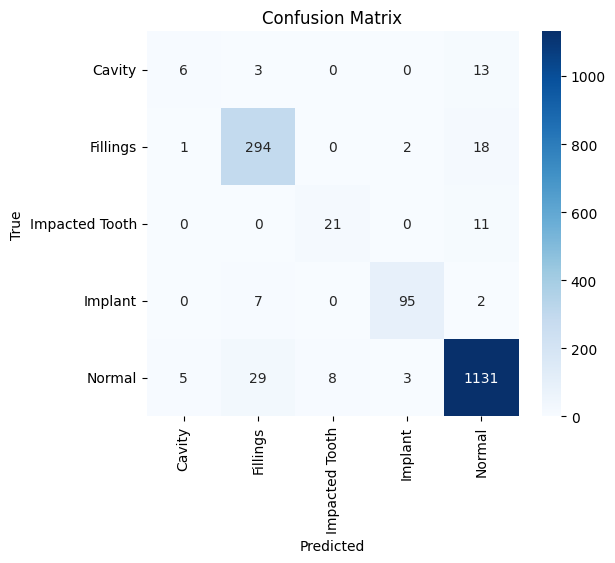


=== Classification Report ===
                precision    recall  f1-score   support

        Cavity     0.5000    0.2727    0.3529        22
      Fillings     0.8829    0.9333    0.9074       315
Impacted Tooth     0.7241    0.6562    0.6885        32
       Implant     0.9500    0.9135    0.9314       104
        Normal     0.9626    0.9617    0.9621      1176

      accuracy                         0.9381      1649
     macro avg     0.8039    0.7475    0.7685      1649
  weighted avg     0.9357    0.9381    0.9363      1649


=== Disease Category-wise Metrics ===
  Disease Category  Precision    Recall  F1-score  Support
0           Cavity   0.500000  0.272727  0.352941       22
1         Fillings   0.882883  0.933333  0.907407      315
2   Impacted Tooth   0.724138  0.656250  0.688525       32
3          Implant   0.950000  0.913462  0.931373      104
4           Normal   0.962553  0.961735  0.962144     1176

=== Specificity per Class ===
Cavity: 0.9963
Fillings: 0.9708
Impact

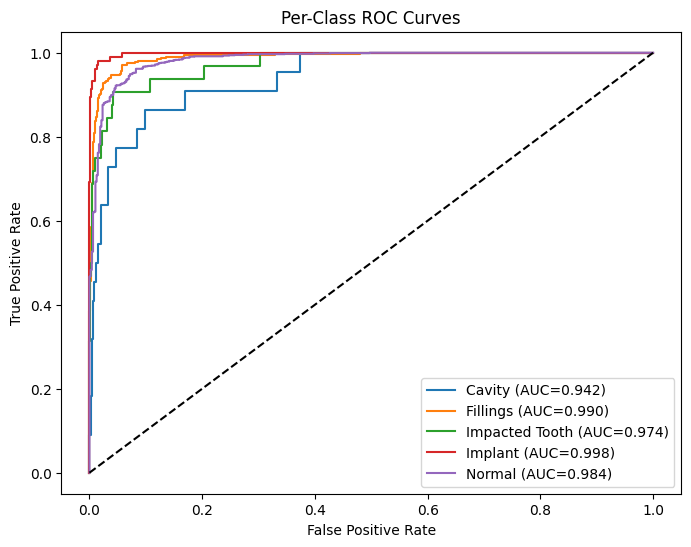

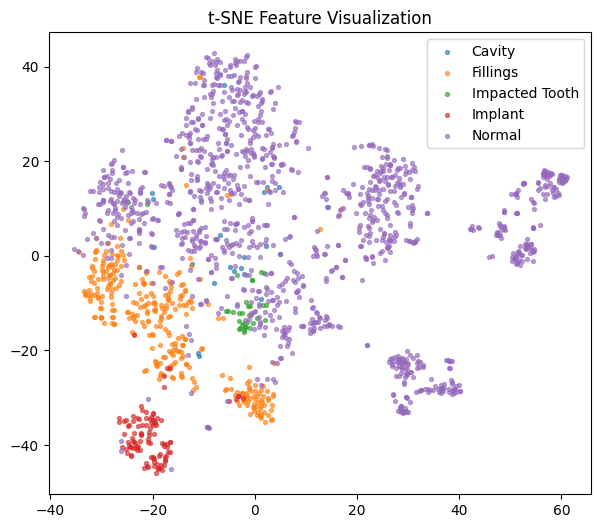


Overall Test Accuracy: 0.9381


In [17]:
# ==============================
# Stage 3 — Evaluation (Single Dataset)
# ==============================

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------
# 1️⃣ Load test dataset
# ------------------------------
# Make sure test_ds is already defined
bs = 32
test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=4)

# ------------------------------
# 2️⃣ Load trained model
# ------------------------------
ckpt = torch.load("best_finetuned_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
model.to(device)
print("✅ Model loaded")

# ------------------------------
# 3️⃣ Collect predictions & features
# ------------------------------
y_true = []
y_logits = []
feats_all = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        feats = model.backbone(imgs)
        if feats.dim() > 2:
            feats = torch.flatten(feats, 1)
        logits = model.head(feats)

        y_true.append(labels.cpu().numpy())
        y_logits.append(logits.cpu().numpy())
        feats_all.append(feats.cpu().numpy())

y_true = np.concatenate(y_true)
y_logits = np.concatenate(y_logits)
y_prob = F.softmax(torch.tensor(y_logits), dim=1).numpy()
y_pred = np.argmax(y_prob, axis=1)

# ------------------------------
# 4️⃣ Confusion matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------
# 5️⃣ Classification report & per-class metrics
# ------------------------------
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Optional: tabular per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
report_df = pd.DataFrame({
    "Disease Category": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "Support": support
})
print("\n=== Disease Category-wise Metrics ===")
print(report_df)

# ------------------------------
# 6️⃣ Per-class specificity
# ------------------------------
specificity_per_class = []
for i in range(len(class_names)):
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    FP = cm[:, i].sum() - cm[i, i]
    specificity = TN / (TN + FP)
    specificity_per_class.append(specificity)

print("\n=== Specificity per Class ===")
for cname, spec in zip(class_names, specificity_per_class):
    print(f"{cname}: {spec:.4f}")

# ------------------------------
# 7️⃣ Per-class ROC curves
# ------------------------------
y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
plt.figure(figsize=(8,6))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves")
plt.legend()
plt.show()

# ------------------------------
# 8️⃣ Feature visualization (t-SNE)
# ------------------------------
feats_all = np.concatenate(feats_all)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
fe2 = tsne.fit_transform(feats_all)

plt.figure(figsize=(7,6))
for i, cname in enumerate(class_names):
    sel = y_true == i
    plt.scatter(fe2[sel,0], fe2[sel,1], label=cname, s=8, alpha=0.6)
plt.legend()
plt.title("t-SNE Feature Visualization")
plt.show()

# ------------------------------
# ✅ Done
# ------------------------------
acc = (y_pred == y_true).mean()
print(f"\nOverall Test Accuracy: {acc:.4f}")


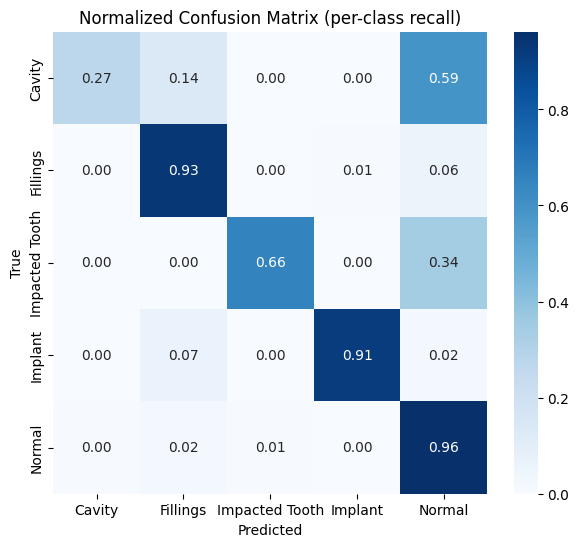

In [18]:
# Get predicted labels
y_pred = np.argmax(y_prob, axis=1)

# Normalized (row-wise)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]
plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Normalized Confusion Matrix (per-class recall)")
plt.show()

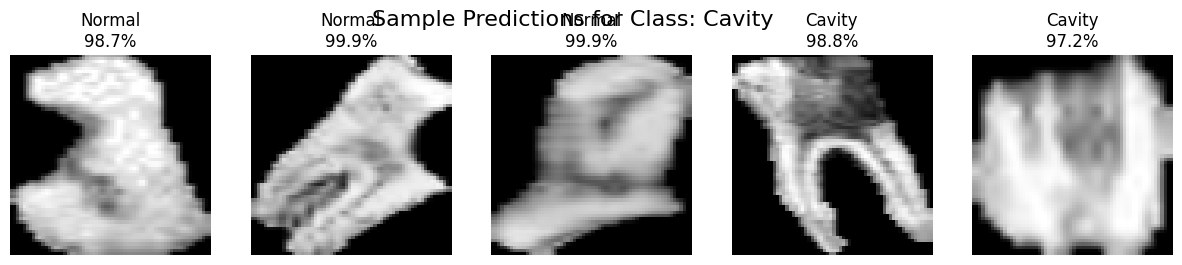

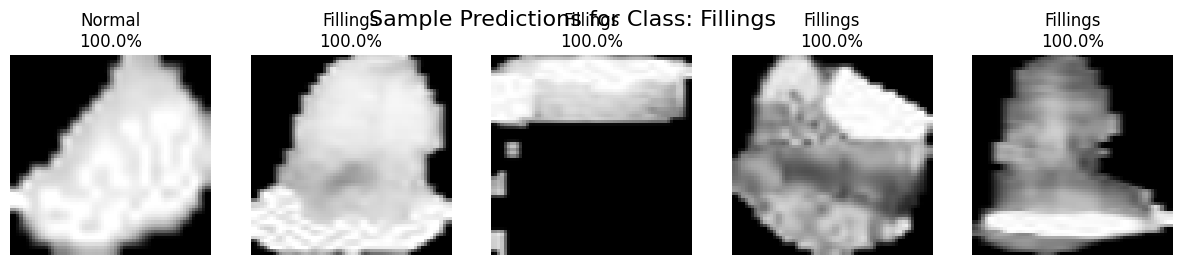

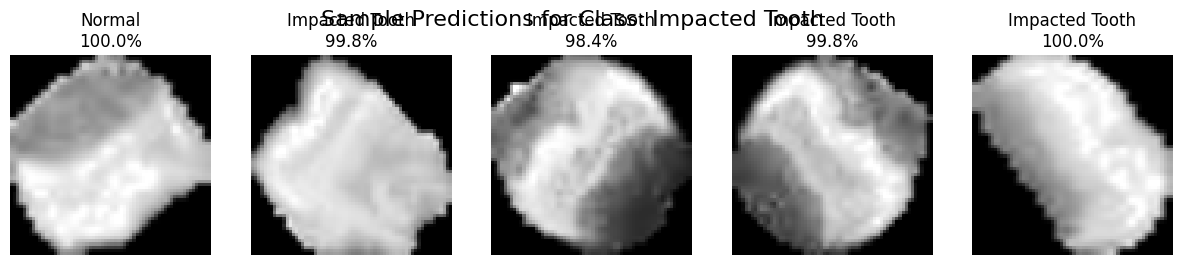

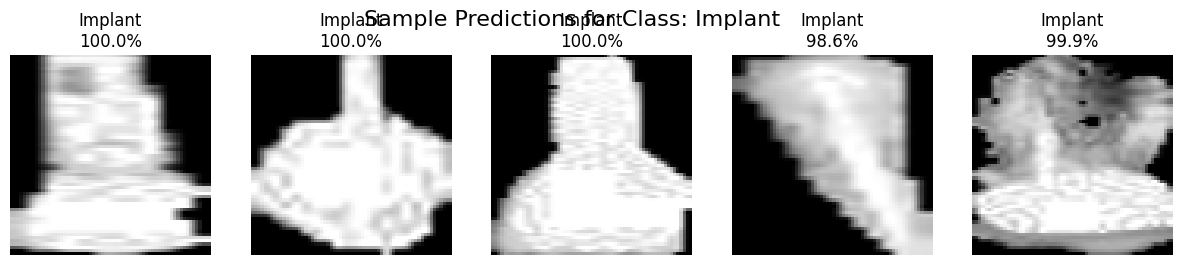

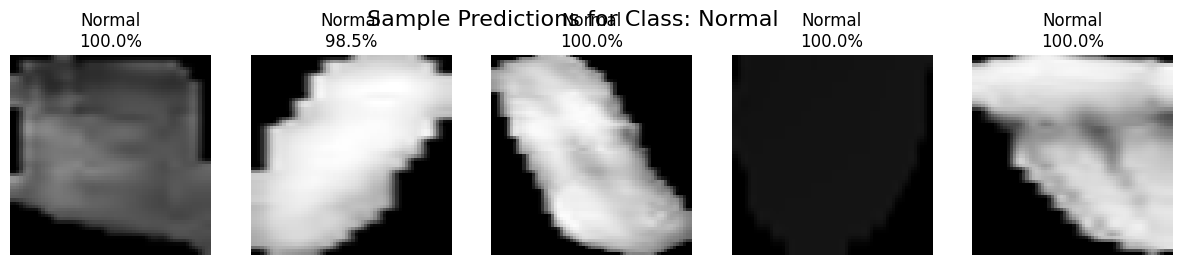

In [13]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob
import random

# --- Settings ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root_test_folder = "/kaggle/input/dental-radiography-segmentation/Dental_Radiography/test"
class_names = ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant', 'Normal']

# --- Transform ---
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Ensure models are in eval mode and on correct device ---
backbone.to(device).eval()
task_classifier.to(device).eval()

# --- Function to predict class ---
def predict_class(img_path):
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = backbone(input_tensor)
        if len(features.shape) > 2:
            features = torch.flatten(features, start_dim=1)
        outputs = task_classifier(features)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    return img, class_names[pred_idx.item()], conf.item()

# --- Plot grid of 5 images per class ---
num_samples = 5

for class_folder in class_names:
    folder_path = os.path.join(root_test_folder, class_folder)
    img_files = glob.glob(os.path.join(folder_path, "*.*"))
    
    if len(img_files) == 0:
        continue
    
    # Randomly pick 5 images (or fewer if less available)
    sample_files = random.sample(img_files, min(num_samples, len(img_files)))

    plt.figure(figsize=(15,3))
    for i, img_file in enumerate(sample_files):
        img, pred_class, conf = predict_class(img_file)
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"{pred_class}\n{conf*100:.1f}%")
        plt.axis('off')
    plt.suptitle(f"Sample Predictions for Class: {class_folder}", fontsize=16)
    plt.show()
